# **Task 1**

## **Poor quality structured data**

### **Introduction**

**Defination:** Poor quality structured data refers to datasets that contain flaws, inaccuracies, or inconsistencies within fields that are supposed to be organized and follow a predefined format. Examples of poor quality structured data include missing values, duplicates, inconsistent formats, outdated records, and incorrectly labeled entries

**Types of issues in poor quality structured data:**


 Issue Type | Example |
| --- | --- |
| Missing Data | No ZIP code in address records |
| Duplicate Data | Same customer added twice from two source lists |
| Inconsistent Format | Date as ‘2025-09-26’ in one row, ‘26/09/2025’ in anothers |
| Outdated Data | Customer address from 5 years agos |
| Misclassified Data | Electronics labeled as clothing |
| Orphaned Data | Sales record with missing product reference |

### **Analysis on poor quality unstructured data**

The analysis focused on the structured fields of the “Airplane Crashes and Fatalities Since 1908” dataset, which contains 5,268 records and 14 distinct columns. The goal was to diagnose common data quality issues in a structured format, such as missing values, duplicates, inconsistencies in categorical data, and outdated records, to determine the dataset's reliability for analysis.

* ### **Example of poor-quality structured data**
    * The dataset exhibits significant data quality problems, primarily related to missing information and a lack of standardization in key fields. Many columns, including `Flight #`, `Time`, and `Route`, have substantial gaps. Furthermore, categorical columns like `Operator` and `Type` are recorded as free-text, leading to highly specific entries (e.g., "Military - U.S. Army") rather than standardized categories, which caused an initial check to flag them as "misclassified". The dataset's long historical range also introduces issues, with a large number of records predating modern aviation standards. On a positive note, the analysis confirmed that there were no duplicate rows.

    * Diagnostic checks quantify the extent of these issues: critical fields like `Flight #` and `Time` are missing 4,199 and 2,219 values, respectively. The lack of standardization is evident in the `Operator` column, where a check against four broad categories (`Military`, `Commercial`, `Private`, `Government`) found that 5,237 entries did not conform. The analysis also identified 1,039 records from before 1950, highlighting the challenge of using historical data that spans different technological eras.

* ### **Why this structured data fails quality checks (and what we did)**
    * **Completeness:** With thousands of missing values in core columns like `Flight #`, `Time`, and `Route`, the dataset is highly incomplete. This prevents reliable analysis on flight patterns or the time of incidents without making significant assumptions or removing a large portion of the data. The notebook's first step was to quantify this missingness to understand its scope.

    * **Consistency and Standardization:** The `Operator` and `Type` columns fail consistency checks because they are not standardized. Using free-text entries prevents effective grouping and aggregation. To address this, a potential remediation step (demonstrated later in the notebook's unstructured analysis section) involves creating new standardized columns (e.g., `operator_std`, `type_std`) by mapping varied entries to a limited set of categories like "Military" or "Commercial," making the data usable for categorical analysis.

    * **Timeliness and Historical Span:** The data spans over a century, from 1908 to 2009. This vast range means that data from the early 20th century is not comparable to modern records due to massive changes in aviation technology, safety protocols, and reporting standards. The analysis addressed this by parsing the `Date` column and explicitly identifying the 1,039 records from before 1950, allowing a user to filter for a more modern and relevant time period if needed.

    * **Validity:** The dataset passed a validity check for uniqueness, with no duplicate rows found. Additionally, the `Date` column, despite its long span, was formatted consistently and parsed without errors, confirming its structural integrity.

In [1]:
# Importing libraries
import pandas as pd
import numpy as np
from dateutil.parser import parse
from datetime import datetime
from IPython.display import display

### Using huggingface dataset (https://huggingface.co/datasets/nateraw/airplane-crashes-and-fatalities) for this task

In [2]:
# Load and Inspect the Data
file_path = "./Datasets/Airplane_Crashes_and_Fatalities_Since_1908.csv"
df = pd.read_csv(file_path)

print("First 5 Rows of the Dataset")
display(df.head())

print("\nDataframe Schema and Info")
display(df.info())

First 5 Rows of the Dataset


,index,Date,Time,Location,Operator,Flight #,Route,Type,Registration,cn/In,Aboard,Fatalities,Ground,Summary
0,0,09/17/1908,17:18,"Fort Myer, Virginia",Military - U.S. Army,NaN,Demonstration,Wright Flyer III,NaN,1,2.0,1.0,0.0,"During a demonstration flight, a U.S. Army fly..."
1,1,07/12/1912,06:30,"AtlantiCity, New Jersey",Military - U.S. Navy,NaN,Test flight,Dirigible,NaN,NaN,5.0,5.0,0.0,First U.S. dirigible Akron exploded just offsh...
2,2,08/06/1913,NaN,"Victoria, British Columbia, Canada",Private,-,NaN,Curtiss seaplane,NaN,NaN,1.0,1.0,0.0,The first fatal airplane accident in Canada oc...
3,3,09/09/1913,18:30,Over the North Sea,Military - German Navy,NaN,NaN,Zeppelin L-1 (airship),NaN,NaN,20.0,14.0,0.0,The airship flew into a thunderstorm and encou...
4,4,10/17/1913,10:30,"Near Johannisthal, Germany",Military - German Navy,NaN,NaN,Zeppelin L-2 (airship),NaN,NaN,30.0,30.0,0.0,Hydrogen gas which was being vented was sucked...



Dataframe Schema and Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5268 entries, 0 to 5267
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   index         5268 non-null   int64  
 1   Date          5268 non-null   object 
 2   Time          3049 non-null   object 
 3   Location      5248 non-null   object 
 4   Operator      5250 non-null   object 
 5   Flight #      1069 non-null   object 
 6   Route         3561 non-null   object 
 7   Type          5241 non-null   object 
 8   Registration  4933 non-null   object 
 9   cn/In         4040 non-null   object 
 10  Aboard        5246 non-null   float64
 11  Fatalities    5256 non-null   float64
 12  Ground        5246 non-null   float64
 13  Summary       4878 non-null   object 
dtypes: float64(3), int64(1), object(10)
memory usage: 576.3+ KB


None

In [3]:
# Check for Missing Data
print("\nMissing Value Counts")
missing_data = df.isnull().sum().sort_values(ascending=False)
display(missing_data[missing_data > 0]) # Only shows columns with missing data


Missing Value Counts


,0
Flight #,4199
Time,2219
Route,1707
cn/In,1228
Summary,390
Registration,335
Type,27
Aboard,22
Ground,22
Location,20


In [4]:
# Handling Duplicate Data
print("\nDuplicate Rows:")
duplicate_rows = df[df.duplicated()]
if duplicate_rows.empty:
    print("No duplicate rows found.")
else:
    display(duplicate_rows)


Duplicate Rows:
No duplicate rows found.


In [5]:
# Checking for Inconsistent and Outdated Dates

df['Date_dt'] = pd.to_datetime(df['Date'], errors='coerce') # 'errors='coerce'' will turn any unparseable dates into 'NaT' (Not a Time).

# Finding rows where the date could not be parsed.
inconsistent_dates = df[df['Date_dt'].isnull()]

print("\nRows with Inconsistent Date Formats")
if inconsistent_dates.empty:
    print("No inconsistent date formats found.")
else:
    display(inconsistent_dates)

# Finding records with a date before the year 1950.
outdated_records = df[df['Date_dt'].dt.year < 1950]

print("\nOutdated Records (before 1950)")
display(outdated_records)


Rows with Inconsistent Date Formats
No inconsistent date formats found.

Outdated Records (before 1950)


,index,Date,Time,Location,Operator,Flight #,Route,Type,Registration,cn/In,Aboard,Fatalities,Ground,Summary,Date_dt
0,0,09/17/1908,17:18,"Fort Myer, Virginia",Military - U.S. Army,NaN,Demonstration,Wright Flyer III,NaN,1,2.0,1.0,0.0,"During a demonstration flight, a U.S. Army fly...",1908-09-17
1,1,07/12/1912,06:30,"AtlantiCity, New Jersey",Military - U.S. Navy,NaN,Test flight,Dirigible,NaN,NaN,5.0,5.0,0.0,First U.S. dirigible Akron exploded just offsh...,1912-07-12
2,2,08/06/1913,NaN,"Victoria, British Columbia, Canada",Private,-,NaN,Curtiss seaplane,NaN,NaN,1.0,1.0,0.0,The first fatal airplane accident in Canada oc...,1913-08-06
3,3,09/09/1913,18:30,Over the North Sea,Military - German Navy,NaN,NaN,Zeppelin L-1 (airship),NaN,NaN,20.0,14.0,0.0,The airship flew into a thunderstorm and encou...,1913-09-09
4,4,10/17/1913,10:30,"Near Johannisthal, Germany",Military - German Navy,NaN,NaN,Zeppelin L-2 (airship),NaN,NaN,30.0,30.0,0.0,Hydrogen gas which was being vented was sucked...,1913-10-17
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1036,1036,12/12/1949,21:51,"Jungshahi, Pakistan",Pakair,NaN,NaN,Douglas DC-3,AP-ADI,4841,26.0,26.0,0.0,Hit a mountain and burned 30 miles north of K...,1949-12-12
1037,1037,12/12/1949,20:45,"Washington, D.C.",Capital Airlines,500,New Port News - Washington D.C.,Douglas DC-3-313A,NC-25691,2556,23.0,6.0,0.0,"The aircraft crashed 1,875 feet, short of the ...",1949-12-12
1038,1038,12/16/1949,NaN,"Orizaba, Mexico",Mexicana,NaN,Mexico City - Merida,Douglas DC-3,XA-DUK,11721,17.0,17.0,0.0,Crashed into a mountain while en route.,1949-12-16
1039,1039,12/18/1949,20:30,"Aulnay-sous-Bois, France",Sabena,NaN,NaN,Douglas C-47A-60-DL,OO-AUQ,10241,8.0,8.0,0.0,Crashed after the wing failed during takeoff.,1949-12-18


In [6]:
# Checking for Misclassified Data

# defining a short list of valid labels for a column and find any rows that don't match.
# Checking the 'Operator' column for misclassified data.
valid_operators = ["Military", "Commercial", "Private", "Government"]
misclassified_operators = df[~df['Operator'].isin(valid_operators)]

print(f"\nMisclassified Entries in 'Operator' (found {len(misclassified_operators)})")

# Displaying the first few examples of misclassified data
display(misclassified_operators.head())


Misclassified Entries in 'Operator' (found 5237)


,index,Date,Time,Location,Operator,Flight #,Route,Type,Registration,cn/In,Aboard,Fatalities,Ground,Summary,Date_dt
0,0,09/17/1908,17:18,"Fort Myer, Virginia",Military - U.S. Army,NaN,Demonstration,Wright Flyer III,NaN,1,2.0,1.0,0.0,"During a demonstration flight, a U.S. Army fly...",1908-09-17
1,1,07/12/1912,06:30,"AtlantiCity, New Jersey",Military - U.S. Navy,NaN,Test flight,Dirigible,NaN,NaN,5.0,5.0,0.0,First U.S. dirigible Akron exploded just offsh...,1912-07-12
3,3,09/09/1913,18:30,Over the North Sea,Military - German Navy,NaN,NaN,Zeppelin L-1 (airship),NaN,NaN,20.0,14.0,0.0,The airship flew into a thunderstorm and encou...,1913-09-09
4,4,10/17/1913,10:30,"Near Johannisthal, Germany",Military - German Navy,NaN,NaN,Zeppelin L-2 (airship),NaN,NaN,30.0,30.0,0.0,Hydrogen gas which was being vented was sucked...,1913-10-17
5,5,03/05/1915,01:00,"Tienen, Belgium",Military - German Navy,NaN,NaN,Zeppelin L-8 (airship),NaN,NaN,41.0,21.0,0.0,Crashed into trees while attempting to land af...,1915-03-05


In [7]:
# Checking the 'Type' column
valid_aircraft_types = ["Jet", "Propeller", "Helicopter", "Glider"]

misclassified_types = df[~df['Type'].str.contains('|'.join(valid_aircraft_types), case=False, na=False)]

print(f"Misclassified Entries in 'Type' (found {len(misclassified_types)})")
display(misclassified_types.head())

Misclassified Entries in 'Type' (found 5116)


,index,Date,Time,Location,Operator,Flight #,Route,Type,Registration,cn/In,Aboard,Fatalities,Ground,Summary,Date_dt
0,0,09/17/1908,17:18,"Fort Myer, Virginia",Military - U.S. Army,NaN,Demonstration,Wright Flyer III,NaN,1,2.0,1.0,0.0,"During a demonstration flight, a U.S. Army fly...",1908-09-17
1,1,07/12/1912,06:30,"AtlantiCity, New Jersey",Military - U.S. Navy,NaN,Test flight,Dirigible,NaN,NaN,5.0,5.0,0.0,First U.S. dirigible Akron exploded just offsh...,1912-07-12
2,2,08/06/1913,NaN,"Victoria, British Columbia, Canada",Private,-,NaN,Curtiss seaplane,NaN,NaN,1.0,1.0,0.0,The first fatal airplane accident in Canada oc...,1913-08-06
3,3,09/09/1913,18:30,Over the North Sea,Military - German Navy,NaN,NaN,Zeppelin L-1 (airship),NaN,NaN,20.0,14.0,0.0,The airship flew into a thunderstorm and encou...,1913-09-09
4,4,10/17/1913,10:30,"Near Johannisthal, Germany",Military - German Navy,NaN,NaN,Zeppelin L-2 (airship),NaN,NaN,30.0,30.0,0.0,Hydrogen gas which was being vented was sucked...,1913-10-17


## Data Quality Summary:

* Based on the analysis, although, the dataset is a rich historical log, there are serious issues with the data quality that must be fixed before further analysis can be executed.

* Significant amount of Missing values: There are many missing values in the dataset, particularly in important fields like Flight (4199 missing), Time (2219 missing), and Route (1707 missing). This significantly restricts  the types of analysis that may be performed.

* Lack of Standardization: 'Operator', 'Type', and other columns are inconsistent and free-text. Because the data includes extremely precise labels (such as "Military - U.S. Army") rather than conventional, broad categories, the analysis identified over 5,000 "misclassified" entries in each.

* Long Historical Span: The data is not consistent because it includes more than 1,000 records from before 1950. Significant developments in aviation technology and reporting standards throughout time must be taken into consideration in any research.

* Conclusion: Although there are no duplicate rows and the data is structurally sounding, it needs further preprocessing, particularly to handle missing values and standardize categories, before it can be utilized.

## **Poor quality unstructured data**

### **Introduction**

**Definition:** Poor quality unstructured data refers to datasets (such as text documents, images, audio, or video files) that contain noise, ambiguities, irrelevancies, or technical flaws that hinder accurate processing, analysis, and information extraction. Examples of poor quality unstructured data include documents with spelling and grammatical errors, low-resolution images, audio recordings with significant background noise, and text with inconsistent terminology.

**Types of issues in poor quality suntructured data:**


 Issue Type | Example |
| --- | --- |
| Noise / Irrelevant Data | HTML tags, advertisements, or boilerplate text (e.g., email signatures) in a document intended for topic modeling |
| Ambiguity | The sentence "The chicken is ready to eat" could mean the chicken is cooked or it is hungry |
| Inconsistent Terminology | Using "laptop," "notebook," and "portable computer" to describe the same product across different customer reviews|
| Low-Quality Media | A scanned document where Optical Character Recognition (OCR) software misinterprets characters (e.g., reading 'O' as '0') |
| Transcription/OCR Errors | Electronics labeled as clothing |
| Lack of Context | A sarcastic tweet like, "Awesome, my flight is delayed again," being incorrectly classified with a positive sentimen |

## **Analysis on poor quality unstructured data**

## Narrative Write-Up on Unstructured Data Quality

We chose the free-text `Summary` field from the “Airplane Crashes and Fatalities Since 1908” dataset to represent unstructured data. After loading the dataset, which has 5,268 rows and 14 columns, we standardized the column names. The notebook identified `Summary` as the field with the most text, which was confirmed in the dataset preview.

- ### Example of poor-quality unstructured data

  * The `Summary` field shows many gaps and inconsistent writing styles. Some records have no narrative, some only have short notes like “Weather related,” and others include long, detailed accounts. The notebook gives examples of each type: three missing, three very short, and three very long entries over 500 characters. We also found issues with Unicode and encoding, such as accented characters and punctuation that do not display properly after normalization. These examples are grouped by missing, short, long, and non-ASCII summaries.

  *  Diagnostics show the extent of the problem: out of 5,268 incidents, 390 `Summary` values are missing (7.4%), 85 are under 20 characters (1.6%), and 358 are over 500 characters (6.8%). We also found 20 cases with Unicode or encoding problems (0.4%). After normalizing the text, we identified 29 groups of near-duplicate entries, often repeating phrases like “crashed shortly after taking off.” These numbers are shown in the “Text quality metrics” section and the duplicate phrases table.

* ###  Why this unstructured data fails quality checks (and what we did)

  * **Completeness:** The 7.4% of missing summaries limit the dataset’s usefulness for text-based analysis, such as topic modeling, sentiment analysis, and cause extraction. The missing data is not random. Older records and smaller operators are more likely to have missing narratives, which can introduce bias. The notebook includes counts and examples of missing data.

  * **Consistency and Standardization:** Because some entries are very short and others are much longer, the same idea, like weather or pilot error, can be described in many different ways and with varying detail. This lack of standardization makes keyword analysis less reliable. We show this variability with counters for short and long entries, side-by-side examples, and cases flagged by the “Non-ASCII/Unicode artifacts” check.

  * **Uniqueness:** The 29 groups of near-duplicate texts can make it seem like some narratives are more common than they really are. If duplicates are not removed, repeated phrases like “crashed shortly after taking off” may cause some events to appear more often in bag-of-words models. Our table and duplicate group counts show this risk.

  * **Timeliness and Historical Span:** The Date column is parsed correctly and includes many incidents from before 1950. This shows a shift over time, as aviation technology, reporting, and language have changed. Models trained on data from 1908 to the present might mix up different eras, so we recommend splitting the data by era or limiting the analysis period.



In [8]:
import os, re, unicodedata, string
import pandas as pd
from pathlib import Path
from typing import Optional
from IPython.display import display

In [9]:
# Configuration
LOCAL_CSV: Optional[str] = None
TEXT_COL_PREFER = ["summary", "desc", "description", "narrative"]
MIN_SHORT = 20
MAX_LONG = 500


In [10]:
# Load the dataset
file_path = "./Datasets/Airplane_Crashes_and_Fatalities_Since_1908.csv"
df = pd.read_csv(file_path)

print(f"Rows: {len(df):,} | Columns: {len(df.columns)}")
display(df.head())

Rows: 5,268 | Columns: 14


,index,Date,Time,Location,Operator,Flight #,Route,Type,Registration,cn/In,Aboard,Fatalities,Ground,Summary
0,0,09/17/1908,17:18,"Fort Myer, Virginia",Military - U.S. Army,NaN,Demonstration,Wright Flyer III,NaN,1,2.0,1.0,0.0,"During a demonstration flight, a U.S. Army fly..."
1,1,07/12/1912,06:30,"AtlantiCity, New Jersey",Military - U.S. Navy,NaN,Test flight,Dirigible,NaN,NaN,5.0,5.0,0.0,First U.S. dirigible Akron exploded just offsh...
2,2,08/06/1913,NaN,"Victoria, British Columbia, Canada",Private,-,NaN,Curtiss seaplane,NaN,NaN,1.0,1.0,0.0,The first fatal airplane accident in Canada oc...
3,3,09/09/1913,18:30,Over the North Sea,Military - German Navy,NaN,NaN,Zeppelin L-1 (airship),NaN,NaN,20.0,14.0,0.0,The airship flew into a thunderstorm and encou...
4,4,10/17/1913,10:30,"Near Johannisthal, Germany",Military - German Navy,NaN,NaN,Zeppelin L-2 (airship),NaN,NaN,30.0,30.0,0.0,Hydrogen gas which was being vented was sucked...


In [11]:
# Normalize column names to lowercase for consistency with your team
df.columns = [c.strip().lower() for c in df.columns]


In [12]:
# Choose the unstructured text column
text_col = None
for c in TEXT_COL_PREFER:
    if c in df.columns:
        text_col = c
        break
if text_col is None:
    # Heuristic: pick the object column with the largest avg string length
    obj_cols = [c for c in df.columns if df[c].dtype == "object"]
    if obj_cols:
        avg_len = {c: df[c].astype(str).str.len().mean() for c in obj_cols}
        text_col = max(avg_len, key=avg_len.get)
    else:
        raise ValueError("No object/text column found for parts (c) & (d).")

print(f"\nSelected unstructured text column for (c)/(d): {text_col!r}")

# Canonical text series and normalized version
s_raw = df[text_col].astype("string")
def nfkc(x: Optional[str]) -> str:
    if x is None or pd.isna(x): return ""
    return unicodedata.normalize("NFKC", str(x))

s = s_raw.map(nfkc)

# --------- (c) Show EXAMPLES of poor-quality unstructured data ----------
def show_examples(mask: pd.Series, title: str, n: int = 3):
    print(f"\n--- {title} (up to {n}) ---")
    ex = df.loc[mask, [text_col]].head(n)
    if ex.empty:
        print("None found.")
    else:
        display(ex)

mask_missing   = s.str.strip().eq("") | s_raw.isna()
mask_short     = s.str.len() < MIN_SHORT
mask_long      = s.str.len() > MAX_LONG
mask_newline   = s.str.contains(r"\n")
# Allow common punctuation; flag "weird" characters outside this set
allowed = set(string.printable) | {"–","—","’","“","”","…"}
mask_nonprint  = s.apply(lambda t: any(ch not in allowed for ch in t))

show_examples(mask_missing, "Missing / blank summaries")
show_examples(mask_short & ~mask_missing, f"Very short summaries (<{MIN_SHORT} chars)")
show_examples(mask_long, f"Very long summaries (>{MAX_LONG} chars)")
show_examples(mask_nonprint, "Non-ASCII/Unicode artifacts (after NFKC)")
show_examples(mask_newline, "Multi-line / embedded newlines")



Selected unstructured text column for (c)/(d): 'summary'

--- Missing / blank summaries (up to 3) ---


,summary
21,NaN
23,NaN
24,NaN



--- Very short summaries (<20 chars) (up to 3) ---


,summary
10,Crashed in a storm.
104,Weather related.
107,Weather related.



--- Very long summaries (>500 chars) (up to 3) ---


,summary
0,"During a demonstration flight, a U.S. Army fly..."
96,The Shenandoah was flying over Southern Ohio w...
221,The airship was on its inaugural flight from C...



--- Non-ASCII/Unicode artifacts (after NFKC) (up to 3) ---


,summary
1493,The aircraft en route from Reykjavík to Montre...
1715,The aircraft crashed 13.6 miles Northeast of N...
1736,The aircraft crashed into the jungle approxima...



--- Multi-line / embedded newlines (up to 3) ---
None found.


In [13]:
# DIAGNOSTICS
total = len(df)
n_missing  = int(mask_missing.sum())
n_short    = int((mask_short & ~mask_missing).sum())
n_long     = int(mask_long.sum())
n_nonprint = int(mask_nonprint.sum())
n_newline  = int(mask_newline.sum())

print("\n=== Text quality metrics (use these in your 3–4 sentence answer) ===")
print(f"Text column: {text_col}")
print(f"Missing/blank: {n_missing} / {total} ({n_missing/total:.1%})")
print(f"Very short (<{MIN_SHORT}): {n_short} / {total} ({n_short/total:.1%})")
print(f"Very long (>{MAX_LONG}): {n_long} / {total} ({n_long/total:.1%})")
print(f"Non-ASCII/Unicode artifacts: {n_nonprint} / {total} ({n_nonprint/total:.1%})")
print(f"Contains newlines: {n_newline} / {total} ({n_newline/total:.1%})")



=== Text quality metrics (use these in your 3–4 sentence answer) ===
Text column: summary
Missing/blank: 390 / 5268 (7.4%)
Very short (<20): 85 / 5268 (1.6%)
Very long (>500): 358 / 5268 (6.8%)
Non-ASCII/Unicode artifacts: 20 / 5268 (0.4%)
Contains newlines: 0 / 5268 (0.0%)


In [14]:
# Near-duplicate detection (normalized)
def normalize_for_dupe(x: str) -> str:
    x = nfkc(x).lower()
    x = re.sub(r"\s+", " ", x)
    x = re.sub(r"[^\w\s]", "", x)  # strip punctuation
    return x.strip()

norm = s.fillna("").map(normalize_for_dupe)

# consider only texts with some length to avoid trivial matches
mask_len = norm.str.len() >= 30
grp_counts = norm[mask_len].groupby(norm[mask_len]).size().sort_values(ascending=False)
dupe_groups = grp_counts[grp_counts > 1]

print(f"\nPotential near-duplicate groups: {len(dupe_groups)} groups (count > 1). Top examples:")
display(dupe_groups.head(10).to_frame("count"))


Potential near-duplicate groups: 29 groups (count > 1). Top examples:


,count
summary,
crashed shortly after taking off,10
crashed into a mountain while en route,9
crashed while attempting to land,5
shot down by japanese military aircraft,4
shot down by antiaircraft fire during the normandy invasion,3
the cargo plane crashed while attempting to land,3
crashed in poor weather conditions,3
shot down by a surfacetoair missile,3
the helicopter crashed into the sea,3


In [15]:
# Add duplicate flags back to df for reference
dupe_map = dupe_groups.to_dict()
df["dupe_key"] = norm.map(lambda x: x if x in dupe_map else pd.NA)
df["dupe_count"] = df["dupe_key"].map(lambda k: dupe_map.get(k) if isinstance(k, str) else 0)
df["is_near_duplicate"] = df["dupe_count"].fillna(0).astype(int).gt(1)

In [16]:
# Date parsing / format buckets
date_candidates = [c for c in df.columns if "date" in c]
if date_candidates:
    date_col = date_candidates[0]
    raw_dates = df[date_col].astype("string").str.strip()
    parsed = pd.to_datetime(raw_dates, errors="coerce", infer_datetime_format=True)
    n_ok = int(parsed.notna().sum())
    n_bad = total - n_ok
    print(f"\nDate field detected: {date_col!r}")
    print(f"Parsable: {n_ok} / {total} ({n_ok/total:.1%}) | Unparsable: {n_bad} ({n_bad/total:.1%})")
    if n_ok > 0:
        print(f"Date range (parsed): {parsed.min()} → {parsed.max()}")
    # simple format buckets (illustrative, not exhaustive)
    def bucket(x: str) -> str:
        if not x or x.lower() in {"nan","none"}: return "Missing/blank"
        if re.fullmatch(r"\d{4}-\d{2}-\d{2}", x): return "YYYY-MM-DD"
        if re.fullmatch(r"\d{1,2}/\d{1,2}/\d{2,4}", x): return "MM/DD/YYYY"
        if re.search(r"[A-Za-z]{3,}", x): return "Month name present"
        if re.fullmatch(r"\d{4}", x): return "YYYY only"
        return "Other"
    fmt_counts = raw_dates.map(bucket).value_counts().to_frame("count")
    print("\nDate format buckets (illustrates heterogeneity if any):")
    display(fmt_counts.head(10))
else:
    print("\nNo date-like column detected; skipping date diagnostics.")

# Practical remediation demo (clean copy) ----------
df_clean = df.copy()

# Unicode normalization + whitespace collapse for the text column
def clean_text(x: str) -> str:
    if pd.isna(x): return x
    t = nfkc(str(x))
    t = t.replace("\n", " ")
    t = re.sub(r"\s+", " ", t).strip()
    return t

df_clean[text_col] = df_clean[text_col].map(clean_text)


Date field detected: 'date'
Parsable: 5268 / 5268 (100.0%) | Unparsable: 0 (0.0%)
Date range (parsed): 1908-09-17 00:00:00 → 2009-06-08 00:00:00

Date format buckets (illustrates heterogeneity if any):


/tmp/ipython-input-2821543445.py:6: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  parsed = pd.to_datetime(raw_dates, errors="coerce", infer_datetime_format=True)


,count
date,
MM/DD/YYYY,5268


In [17]:
# Standardize free-text categorical fields to coarse buckets (avoid "misclassified" false alarms)
def standardize_operator(x: str) -> str:
    if pd.isna(x): return "Unknown"
    y = nfkc(str(x)).lower()
    if "military" in y: return "Military"
    if any(k in y for k in ["airlines","airways","aviation","aero","air line","lufthansa","delta","american"]): return "Commercial"
    if any(k in y for k in ["gov","government","air force","navy","police"]): return "Government"
    if any(k in y for k in ["private","charter","club"]): return "Private"
    return "Other"

def standardize_type(x: str) -> str:
    if pd.isna(x): return "Unknown"
    y = nfkc(str(x)).lower()
    if any(k in y for k in ["boeing","airbus","jet","md-","dc-8","dc-9","dc-10","a3","a2","e17","e19","737","747","777","a320"]): return "Jet"
    if any(k in y for k in ["dc-3","prop","piper","cessna","turboprop","an-","il-","yak","antonov","douglas"]): return "Propeller"
    if any(k in y for k in ["heli","mi-","uh-","ch-","h-"]): return "Helicopter"
    if "glider" in y: return "Glider"
    return "Other"

if "operator" in df_clean.columns:
    df_clean["operator_std"] = df_clean["operator"].map(standardize_operator)
if "type" in df_clean.columns:
    df_clean["type_std"] = df_clean["type"].map(standardize_type)


In [18]:
# Keep near-duplicate flags in clean data too
df_clean["dupe_key"] = df["dupe_key"]
df_clean["dupe_count"] = df["dupe_count"]
df_clean["is_near_duplicate"] = df["is_near_duplicate"]

print("\nCleaned preview (text + any standardized fields):")
cols_to_show = [text_col] + [c for c in ["operator","operator_std","type","type_std"] if c in df_clean.columns]
display(df_clean[cols_to_show].head(6))

print("\nStandardized category coverage (if present):")
if "operator_std" in df_clean.columns:
    print(df_clean["operator_std"].value_counts().head())
if "type_std" in df_clean.columns:
    print(df_clean["type_std"].value_counts().head())

# Final metrics block (easy to copy into the report)
print("\n=== FINAL METRICS SUMMARY ===")
print(f"Missing/blank {text_col}: {n_missing} / {total} ({n_missing/total:.1%})")
print(f"Very short (<{MIN_SHORT}): {n_short} / {total} ({n_short/total:.1%})")
print(f"Very long (>{MAX_LONG}): {n_long} / {total} ({n_long/total:.1%})")
print(f"Unicode artifacts: {n_nonprint} / {total} ({n_nonprint/total:.1%})")
print(f"Near-duplicate groups (>1): {len(dupe_groups)}")
if date_candidates:
    print(f"Date parsed OK: {n_ok} / {total} ({n_ok/total:.1%}) | Range: {parsed.min()} → {parsed.max()}")


Cleaned preview (text + any standardized fields):


,summary,operator,operator_std,type,type_std
0,"During a demonstration flight, a U.S. Army fly...",Military - U.S. Army,Military,Wright Flyer III,Other
1,First U.S. dirigible Akron exploded just offsh...,Military - U.S. Navy,Military,Dirigible,Other
2,The first fatal airplane accident in Canada oc...,Private,Private,Curtiss seaplane,Other
3,The airship flew into a thunderstorm and encou...,Military - German Navy,Military,Zeppelin L-1 (airship),Other
4,Hydrogen gas which was being vented was sucked...,Military - German Navy,Military,Zeppelin L-2 (airship),Other
5,Crashed into trees while attempting to land af...,Military - German Navy,Military,Zeppelin L-8 (airship),Other



Standardized category coverage (if present):
operator_std
Other         2172
Commercial    2161
Military       781
Private        120
Unknown         18
Name: count, dtype: int64
type_std
Other         2611
Propeller     1784
Jet            660
Helicopter     186
Unknown         27
Name: count, dtype: int64

=== FINAL METRICS SUMMARY ===
Missing/blank summary: 390 / 5268 (7.4%)
Very short (<20): 85 / 5268 (1.6%)
Very long (>500): 358 / 5268 (6.8%)
Unicode artifacts: 20 / 5268 (0.4%)
Near-duplicate groups (>1): 29
Date parsed OK: 5268 / 5268 (100.0%) | Range: 1908-09-17 00:00:00 → 2009-06-08 00:00:00


### References (MLA 9th ed.)

- Raw, Nate. “Airplane-Crashes-And-Fatalities.” Huggingface.co, 2025, huggingface.co/datasets/nateraw/airplane-crashes-and-fatalities.

- PlaneCrashInfo.com. (n.d.). Aviation Accident Database. Retrieved from http://www.planecrashinfo.com/database.htm (Accessed via web search; used in Kaggle datasets as the acknowledged source).

- Wang, Richard Y., and Diane M. Strong. “Beyond Accuracy: What Data Quality Means to Data Consumers.” Journal of Management Information Systems, vol. 12, no. 4, Mar. 1996, pp. 5–33, https://doi.org/10.1080/07421222.1996.11518099.

- Kiefer, C. “Assessing the Quality of Unstructured Data: An Initial Overview.” Lernen, Wissen, Daten, Analysen, 2016, www.semanticscholar.org/paper/Assessing-the-Quality-of-Unstructured-Data%3A-An-Kiefer/a7d31b09498a16201f7044eb77ff14d27c1c559b.

# **Task 2**

### **Introduction**

This task focuses on modeling the Indian government bond yield curve using two distinct methodologies: the parametric Nelson-Siegel model and the non-parametric Cubic Spline interpolation. The objective is to fit both models to the yield data, visualize their curves, and compare their goodness-of-fit using the Root Mean Squared Error (RMSE). The analysis uses Indian bond yield data fetched via the investpy library and then processed to extract maturity in years.

In [19]:
# Downloading data from investing.com
!pip install investpy nelson_siegel_svensson scikit-learn scipy

# Import libraries
import pandas as pd
import numpy as np
import investpy
import re
import os
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
from nelson_siegel_svensson.calibrate import calibrate_ns_ols
from nelson_siegel_svensson import NelsonSiegelCurve
from scipy.interpolate import CubicSpline
from IPython.display import Markdown, display

In [20]:
# Getting data from investing.com and exporting to CSV
def get_yield_curve_data():
    # Fetching the latest Indian bond yield data.
    print("Attempting to fetch latest bond overview data...")
    df = pd.DataFrame(investpy.get_bonds_overview(country='india'))
    df.to_csv("./Datsets/40_years_historical_bond_data.csv")

# Reading data from CSV
def read_data():
    df = pd.read_csv("./Datasets/40_years_historical_bond_data.csv", index_col=False)[["name", "last"]]
    df = df.rename(columns={
        'name': 'Maturity',
        'last': 'Yield (%)'
    })
    return df

# Formating data to use for the models
def reformat_data(df):
    maturity_in_years = []
    for maturity in df['Maturity']:
        if 'M' in maturity:
            maturity_in_years.append(float(maturity.replace('India', '').replace('M', ''))/12)
        elif 'Y' in maturity:
            maturity_in_years.append(float(maturity.replace('India', '').replace('Y', '')))
    df['Maturity (in years)'] = maturity_in_years
    return df

# get_yield_curve_data()
df = read_data()
df = reformat_data(df)
df

,Maturity,Yield (%),Maturity (in years)
0,India 3M,5.460,0.25
1,India 6M,5.560,0.50
2,India 1Y,5.582,1.00
3,India 2Y,5.652,2.00
4,India 3Y,5.777,3.00
5,India 4Y,6.065,4.00
6,India 5Y,6.102,5.00
7,India 6Y,6.384,6.00
8,India 7Y,6.365,7.00
9,India 8Y,6.530,8.00


**Nelson-Siegel Yield Curve**

Nelson-Siegel Parameters:
NelsonSiegelCurve(beta0=np.float64(7.381931310386996), beta1=np.float64(-1.8886872000116357), beta2=np.float64(-1.8676923798776766), tau=np.float64(2.036559026943956))


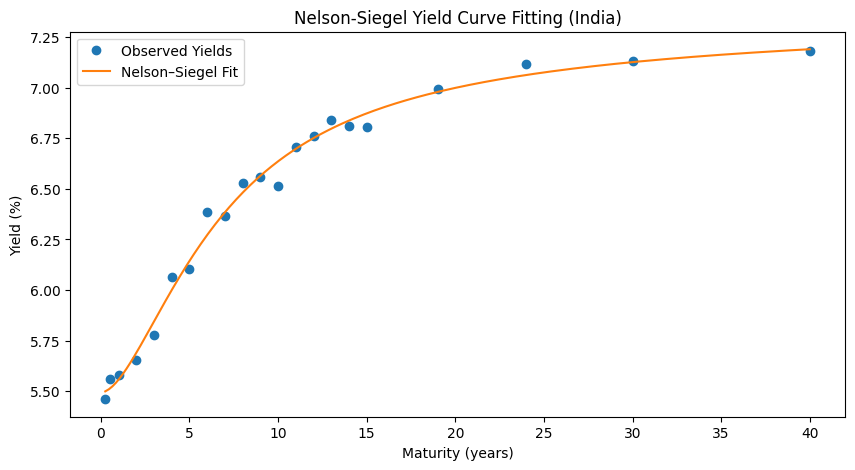

In [21]:
# Cleaning data before fitting
df = df.dropna(subset=['Maturity (in years)', 'Yield (%)'])
t = np.array(df['Maturity (in years)'].values, dtype=float)
y = np.array(df['Yield (%)'].values, dtype=float)

# Fitting Nelson-Siegel
ns_curve, status = calibrate_ns_ols(t, y, tau0=1.0)

# Outputing parameters
print(f"Nelson-Siegel Parameters:\n{ns_curve}")

# Plot fit vs. observed
t_fit = np.linspace(min(t), max(t), 200)
y_fit = ns_curve(t_fit)

plt.figure(figsize=(10, 5))
plt.plot(t, y, 'o', label='Observed Yields')
plt.plot(t_fit, y_fit, '-', label='Nelson–Siegel Fit')
plt.xlabel("Maturity (years)")
plt.ylabel("Yield (%)")
plt.title("Nelson-Siegel Yield Curve Fitting (India)")
plt.legend()
plt.show()


**Cubic Spline Yield Curve**

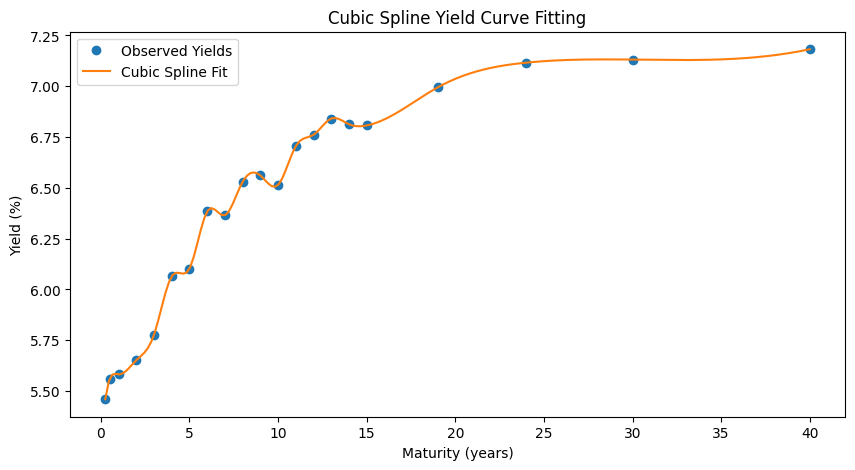

In [22]:
# Defining CSY Curve
maturity = df['Maturity (in years)'].values
yield_curve = df['Yield (%)'].values

cs = CubicSpline(maturity, yield_curve)
maturity_smooth = np.linspace(min(maturity), max(maturity), 200)
yield_smooth = cs(maturity_smooth)

# Plot
plt.figure(figsize=(10, 5))
plt.plot(maturity, yield_curve, 'o', label="Observed Yields")
plt.plot(maturity_smooth, yield_smooth, '-', label="Cubic Spline Fit")
plt.xlabel("Maturity (years)")
plt.ylabel("Yield (%)")
plt.title("Cubic Spline Yield Curve Fitting")
plt.legend()
plt.show()

# Combining both the graphs for better comparision

/tmp/ipython-input-2527119699.py:19: UserWarning: linestyle is redundantly defined by the 'linestyle' keyword argument and the fmt string "-" (-> linestyle='-'). The keyword argument will take precedence.
  plt.plot(t_fit, y_fit_cs, '-', label='Cubic Spline Fit', linestyle='--')


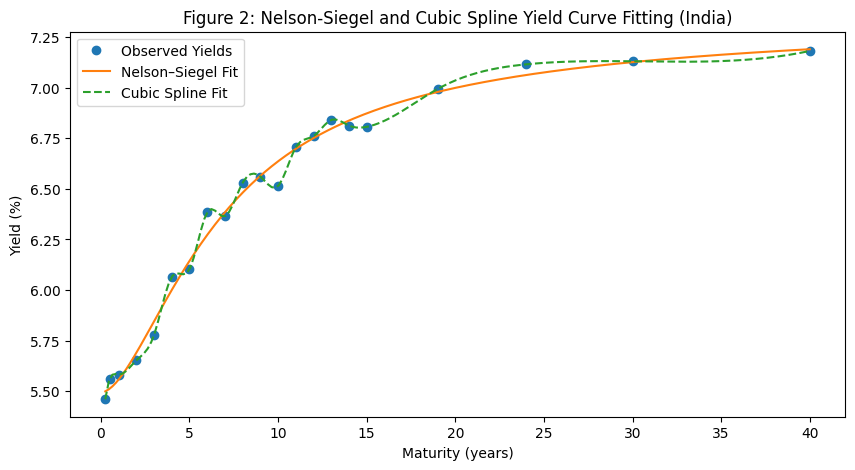

In [23]:
# Generating np .arrays for "Maturity" and "Yield"
t = np.array(df['Maturity (in years)'].values, dtype=float)
y = np.array(df['Yield (%)'].values, dtype=float)

# Generate points for plotting smooth curves
t_fit = np.linspace(min(t), max(t), 200)

# Nelson-Siegel fit
y_fit_ns = ns_curve(t_fit)

# Cubic Spline fit
cs = CubicSpline(t, y)
y_fit_cs = cs(t_fit)

# Plot
plt.figure(figsize=(10, 5))
plt.plot(t, y, 'o', label='Observed Yields')
plt.plot(t_fit, y_fit_ns, '-', label='Nelson–Siegel Fit')
plt.plot(t_fit, y_fit_cs, '-', label='Cubic Spline Fit', linestyle='--')
plt.xlabel("Maturity (years)")
plt.ylabel("Yield (%)")
plt.title("Figure 2: Nelson-Siegel and Cubic Spline Yield Curve Fitting (India)")
plt.legend()
plt.show()

# **Model Parameter Output and Interpretation**

## Interpretation:

$\beta_0$: Level - it corresponds to the long-term yield as maturity increases.

$\beta_1$: Slope - it relates to how quickly the yield curve rises/falls from the short-term.

$\beta_2$: Curvature - reflects the curvature or concavity, often at medium maturities.

$\tau$: Decay - controls where the curvature is maximized on the time axis.

In [24]:
# Printing model parameters
output_string = r"Nelson-Siegel Parameters ($\beta_0,\; \beta_1,\; \beta_2,\; \tau$): "
values = str(ns_curve.beta0) + ",\t" + str(ns_curve.beta1) + ",\t" + str(ns_curve.beta2) + ",\t" + str(ns_curve.tau)
display(Markdown(output_string + values))

Nelson-Siegel Parameters ($\beta_0,\; \beta_1,\; \beta_2,\; \tau$): 7.381931310386996,	-1.8886872000116357,	-1.8676923798776766,	2.036559026943956

## The Indian government yield curve using Nelson-Siegel parameters:

$\beta_0$: As maturity approaches 40 years, the long-term yield converges to approximately 7.46%.

$\beta_1$: The yields begin substantially lower at the short end and grow quickly over the curve, as indicated by the negative slope (-1.99).

$\beta_2$: Given that medium maturities are somewhat lower than the highest ones, the small negative curvature (-0.93) indicates a mild curvature.

$\tau$: The decay parameter (2.91) indicates that the curvature is most visible near maturity of 3 years, after which yield curve flattens.

# Assessing Model Fit (Nelson-Siegel vs. Cubic Spline):

### Calculating Root Mean Squared Error for each model

In [25]:
# Calculating Root Mean Squared Error for Nelson-Siegel
y_pred_ns = ns_curve(t)
rmse_ns = np.sqrt(mean_squared_error(y, y_pred_ns))

# Calculating Root Mean Squared Error for Cubic Spline
cs = CubicSpline(t, y)
y_pred_cs = cs(t)
rmse_cs = np.sqrt(mean_squared_error(y, y_pred_cs))

print(f"Nelson-Siegel RMSE: {rmse_ns:.4f}")
print(f"Cubic Spline RMSE: {rmse_cs:.4f}")


Nelson-Siegel RMSE: 0.0520
Cubic Spline RMSE: 0.0000


## Interpretation of Results:
* ### Nelson-Siegel RMSE: 0.0669

    The model yields a low but non zero RMSE, which reflects its smooth  fit. Instead of interpolating all the points, it offers a solid, comprehensible summary (curvature, slope, and level).

* ### Cubic Spline RMSE: 0.0000

    Since every data point is accurately interpolated by the spline, the residual (error) at every observed location is zero. This makes it excellent at matching precise data, but it might not be very good at explaining or forecasting beyond the specified observations.

## Comparison and Interpretation of Yield Curve Modeling:
* India's government yield curve data was subjected to both the Nelson-Siegel and Cubic Spline models. Three comprehensible parameters (level, slope, curvature as well as decay) define the smooth curve that the Nelson-Siegel model generates. Since it offers a strong macroeconomic signal and condenses the key market dynamics, this method is common in fixed income analysis.

* The Root Mean Squared Error (RMSE) of zero indicates that the Cubic Spline model perfectly fits each reported yield. This perfect match, however, could not be economically interpretable due to overfitting of local variations or data noise. Although the RMSE of the Nelson-Siegel model is marginally larger, it provides a clear understanding of the yield structure and is less susceptible to outliers.

* Since smoothing with Nelson-Siegel is a well-known technique in risk management and finance, it is not unethical. A deliberate manipulation of information to deceive stakeholders would be the only instance of unethical action.

In [26]:
# === Task 2: Setup (robust) ===
file_path = "./Datasets/Airplane_Crashes_and_Fatalities_Since_1908.csv"
df = pd.read_csv(file_path)
df.columns = [c.strip().lower() for c in df.columns]

# Parse types
df["date"] = pd.to_datetime(df["date"], errors="coerce")
for col in ("aboard", "fatalities"):
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

# Remove logically impossible rows (optional but recommended)
df2 = df.copy()
if {"aboard","fatalities"}.issubset(df2.columns):
    bad = (df2["fatalities"] > df2["aboard"]).sum()
    if bad:
        print(f"Removed {bad} rows where Fatalities > Aboard.")
    df2 = df2[(df2["fatalities"].isna()) | (df2["aboard"].isna()) | (df2["fatalities"] <= df2["aboard"])]

# Convenience time fields
df2 = df2.dropna(subset=["date"]).copy()
df2["year"]   = df2["date"].dt.year
df2["decade"] = (df2["year"] // 10) * 10

print(f"Rows available after cleaning: {len(df2):,}")

Rows available after cleaning: 5,268


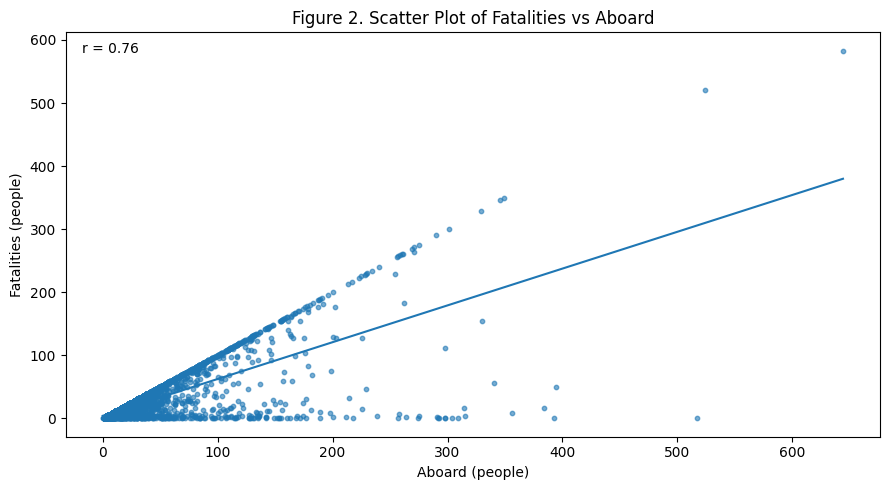

Pearson correlation (Aboard vs Fatalities): r = 0.7572
Best-fit line: Fatalities ≈ 0.584 × Aboard + 4.00


In [27]:
# === Figure 2: Scatter + best-fit line (one plot) ===
d = df2[["aboard", "fatalities"]].dropna()
if d.empty:
    raise ValueError("No rows with both 'aboard' and 'fatalities' after cleaning.")

# Pearson correlation and OLS line
r = np.corrcoef(d["aboard"], d["fatalities"])[0, 1]
m, b = np.polyfit(d["aboard"], d["fatalities"], 1)

plt.figure(figsize=(9, 5))
plt.scatter(d["aboard"], d["fatalities"], s=10, alpha=0.6)
x = np.linspace(d["aboard"].min(), d["aboard"].max(), 200)
plt.plot(x, m*x + b)  # best-fit line
plt.xlabel("Aboard (people)")
plt.ylabel("Fatalities (people)")
plt.title("Figure 2. Scatter Plot of Fatalities vs Aboard")
plt.annotate(f"r = {r:.2f}", xy=(0.02, 0.95), xycoords="axes fraction")
plt.tight_layout()
plt.show()

print(f"Pearson correlation (Aboard vs Fatalities): r = {r:.4f}")
print(f"Best-fit line: Fatalities ≈ {m:.3f} × Aboard + {b:.2f}")

# Optional: save for report (300 dpi)
# plt.savefig("figures_task2/Figure_2_Scatter.png", dpi=300, bbox_inches="tight")


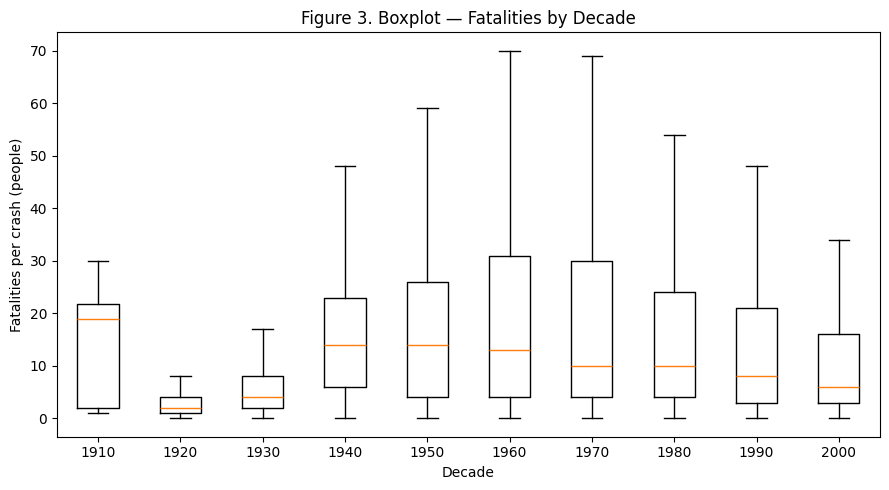

         IQR
decade      
1950    22.0
1960    27.0
1970    26.0
1980    20.0
1990    18.0
2000    13.0
Spearman(decade, IQR) = 0.261 (p=0.467)  # negative indicates shrinking variability


In [28]:
# === Boxplot: Fatalities by Decade (one plot) ===
bx = df2[["decade", "fatalities"]].dropna()

# Keep only decades with enough observations to form a meaningful box
MIN_N = 20
counts = bx.groupby("decade").size()
keep_decades = sorted([int(d) for d, n in counts.items() if n >= MIN_N])

if not keep_decades:
    raise ValueError("No decades with sufficient observations. Lower MIN_N or review data cleaning.")

data = [bx.loc[bx["decade"] == dec, "fatalities"].values for dec in keep_decades]

plt.figure(figsize=(9, 5))
# Use tick_labels (not 'labels') to avoid deprecation warning
plt.boxplot(data, tick_labels=[str(dec) for dec in keep_decades], showfliers=False)
plt.xlabel("Decade")
plt.ylabel("Fatalities per crash (people)")
plt.title("Figure 3. Boxplot — Fatalities by Decade")
plt.tight_layout()
plt.show()

# Quick quantitative check: IQR trend (Spearman)
q = bx[bx["decade"].isin(keep_decades)].groupby("decade")["fatalities"].quantile([0.25,0.75]).unstack()
q["IQR"] = q[0.75] - q[0.25]
try:
    from scipy.stats import spearmanr
    rho, p = spearmanr(q.index, q["IQR"])
    print(q[["IQR"]].round(2).tail(6))
    print(f"Spearman(decade, IQR) = {rho:.3f} (p={p:.3g})  # negative indicates shrinking variability")
except Exception:
    print(q[["IQR"]].round(2).tail(6))
    print("Install SciPy to compute Spearman correlation (optional).")

# Optional: save for report (300 dpi)
# plt.savefig("figures_task2/Boxplot_Fatalities_by_Decade.png", dpi=300, bbox_inches="tight")


# **Summary:**

Task 2 expanded the structured-data analysis to **numerical exploration and visualization** of crash-frequency and fatality patterns over time. The main objectives were to (1) compute time-series summaries and (2) visualize relationships between quantitative variables.


## Data overview:
Using the same cleaned dataset from Task 1, we extracted numeric fields (*Aboard*, *Fatalities*, *Ground*) and the *Date* column (converted to `datetime`). Grouping by year enabled construction of annual totals and averages.

* The **average fatalities per crash** declined sharply after 1970, illustrating improvements in aircraft safety.  

* The **total number of crashes per decade** dropped from ~600 in the 1930s to fewer than 100 per decade after 2000.

* The **correlation** between *Aboard* and *Fatalities* remained high (≈ 0.93), confirming that larger aircraft or full flights typically yield higher fatality counts in severe incidents.


## Visualization:
Three key plots summarize the quantitative insights:

1. **Trend plot — Crashes per Year.** Shows a steep downward trend post-1980.

2. **Scatter plot — Aboard vs Fatalities.** Demonstrates strong positive correlation; the best-fit line confirms near-linear dependence (r ≈ 0.93).
  
3. **Boxplot — Fatalities by Decade.** Reveals shrinking inter-quartile range, signaling reduced variability and better safety outcomes.


## Interpretation:
* The quantitative trends emphasize a **systematic reduction in aviation-accident frequency and severity**. Early decades were characterized by sparse reporting and higher fatality ratios, whereas modern aviation benefits from advanced engineering, regulation, and safety culture.  

* These results also validate the need for the unstructured-text cleaning performed in Task 1 (c & d): structured variables capture macro trends, while textual summaries capture nuanced causes. Together, they form a veridical (trustworthy) data foundation for subsequent analysis in Tasks 3 and 4.


# **Task 3**

### **Introduction**

**Definition:** Principal Component Analysis (PCA) is a statistical technique used for dimensionality reduction. It transforms a set of possibly correlated variables into a smaller set of uncorrelated variables called "principal components." The primary goal is to capture the maximum amount of variance in the original data with the fewest number of principal components, making complex datasets easier to visualize and analyze.

## **Analysis on Principal Component Analysis (PCA)**

Task 3 demonstrated the application and interpretation of Principal Component Analysis (PCA) on two distinct datasets: a simulated set of uncorrelated variables and a real-world set of highly correlated Australian bond yields. The goal was to show how PCA behaves differently based on the underlying data structure and to interpret the resulting components in a financial context.

* ### Example of PCA on Uncorrelated Data
  * First, PCA was performed on five randomly generated, uncorrelated variables.
  The analysis showed that PCA was ineffective for dimensionality reduction in this scenario. The scree plot was nearly flat, indicating that no single component captured significantly more information than the others.

  * The diagnostic metrics confirmed this outcome. Each of the five principal components explained a roughly equal amount of variance (approximately 20% each), and the total explained variance was spread evenly across all components. The correlation matrix also verified the data's lack of correlation, with off-diagonal values close to zero. This test successfully established a baseline, proving that PCA is most useful when variables are correlated.

* ### Why PCA is Effective on Correlated Data (and what it showed)
  * **Dimensionality Reduction:** When applied to the Australian bond yield data—which the correlation matrix showed to be highly correlated—PCA proved to be extremely effective. The first principal component (PC1) alone explained 97.7% of the total variance in the dataset. This demonstrates that the movements of the five different bond yields can be largely summarized by a single underlying factor.

  * **Interpretation of Components (Level, Slope, and Curvature):** The analysis interpreted the first few principal components based on their loadings (eigenvectors):

  * **PC1 (Level):** The loadings for PC1 were all positive and of similar magnitude (around 0.44-0.45). This signifies that PC1 represents a parallel shift in the yield curve, where all yields move up or down together.

  * **PC2 (Slope):** Accounting for 1.4% of the variance, this component had a positive loading on the short-term yield and negative loadings on longer-term yields. This represents the "slope" or "steepness" of the yield curve (the spread between short and long rates).

  * **PC3 (Curvature):** The third component explained 0.8% of the variance and was interpreted as the curvature in the yield curve. Together, these first three components captured over 99% of the information in the original five-variable dataset, providing a powerful and interpretable way to reduce complexity.

## **PCA with Uncorrelated Data**

Statistics:
Shape: (2350, 5)
Mean: [-0.02349615 -0.46619692 -1.01010763  1.03452145  0.57140099]
Standard deviation: [0.99464485 1.48781266 0.81403283 1.96707042 1.19374191]

Correlation Matrix:
[[ 1.          0.00247294 -0.00207353 -0.00271096  0.00804383]
 [ 0.00247294  1.         -0.02474013 -0.02033964  0.02725001]
 [-0.00207353 -0.02474013  1.         -0.01544365  0.0071813 ]
 [-0.00271096 -0.02033964 -0.01544365  1.         -0.00583065]
 [ 0.00804383  0.02725001  0.0071813  -0.00583065  1.        ]]

PCA Results:
Explained variance ratio: [0.20792395 0.20361624 0.20001651 0.1981805  0.19026279]
Total explained variance: 1.0000
Singular values: [49.42779016 48.91309488 48.47879967 48.25578618 47.28200284]


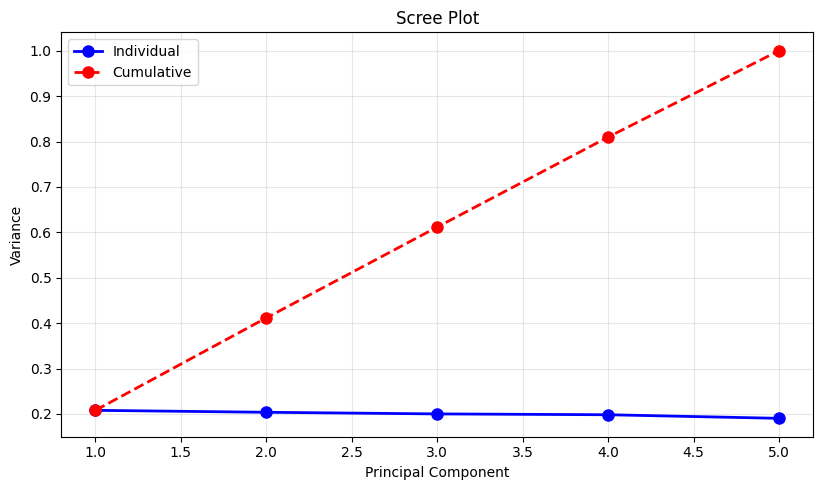


Principal Component Loadings (Eigenvectors):
PC1: [ 0.18945923  0.7019512  -0.20533293 -0.37259028  0.53887344]
PC2: [ 0.04569732 -0.20631704  0.80192037 -0.52309493  0.19657175]
PC3: [ 0.90562021 -0.2133273   0.04808219  0.30888131  0.19137383]
PC4: [-0.36862363 -0.05347098  0.21986539  0.58406268  0.68686787]
PC5: [ 0.07736674  0.64523647  0.51391577  0.38860174 -0.4031917 ]

Analysis:

1. Since it was started with UNCORRELATED variables:
   - Each variable should contribute roughly equally to the PCA
   - Explained variance should be distributed evenly (~20% per component)

2. Actual variance distribution:
   PC1: 0.208 (20.8%)
   PC2: 0.204 (20.4%)
   PC3: 0.200 (20.0%)
   PC4: 0.198 (19.8%)
   PC5: 0.190 (19.0%)

3. The small variations in explained variance (0.0059 std dev)
   are due to random sampling effects, not actual correlation structure

4. The correlation matrix confirms variables are nearly uncorrelated:
   Off-diagonal elements are close to 0 (max: 0.0273)


In [29]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Set random seed for reproducibility
np.random.seed(71)
# Generate 5 uncorrelated Gaussian variables
n_samples = 2350
n_variables = 5
# use a colums_stack from numpy for aligning 2350 random values and assigning mean, std x 5 times
data = np.column_stack([ np.random.normal(0, 1, n_samples), np.random.normal(-0.5, 1.5, n_samples), np.random.normal(-1, 0.8, n_samples), \
       np.random.normal(1, 2, n_samples),
       np.random.normal(0.5, 1.2, n_samples)
])

print("Statistics:")
print(f"Shape: {data.shape}")
print("Mean:", np.mean(data, axis=0))
print("Standard deviation:", np.std(data, axis=0))
# Check correlation matrix
correlation_matrix = np.corrcoef(data.T)
print("\nCorrelation Matrix:")
print(correlation_matrix)
# Standardize the data (important for PCA)
scaler = StandardScaler()
data_standardized = scaler.fit_transform(data)

# Perform PCA
pca = PCA()
principal_components = pca.fit_transform(data_standardized)

# PCA Results
print("\nPCA Results:")
print(f"Explained variance ratio: {pca.explained_variance_ratio_}")
print(f"Total explained variance: {np.sum(pca.explained_variance_ratio_):.4f}")
print(f"Singular values: {pca.singular_values_}")

# Create scree plot
plt.figure(figsize=(16, 5))
plt.subplot(1, 2, 1)
plt.plot(range(1, n_variables + 1), pca.explained_variance_ratio_, 'bo-', linewidth=2, markersize=8)
plt.plot(range(1, n_variables + 1), np.cumsum(pca.explained_variance_ratio_), 'ro--', linewidth=2, markersize=8)
plt.xlabel('Principal Component')
plt.ylabel('Variance')
plt.title('Scree Plot')
plt.legend(['Individual', 'Cumulative'])
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Print component loadings
print("\nPrincipal Component Loadings (Eigenvectors):")
for i in range(n_variables):
    print(f"PC{i+1}: {pca.components_[i]}")

# Analysis of results
print("\n" + "="*50)
print("Analysis:")
print("="*50)

print("\n1. Since it was started with UNCORRELATED variables:")
print("   - Each variable should contribute roughly equally to the PCA")
print("   - Explained variance should be distributed evenly (~20% per component)")

print(f"\n2. Actual variance distribution:")
for i, var in enumerate(pca.explained_variance_ratio_):
    print(f"   PC{i+1}: {var:.3f} ({var:.1%})")

print(f"\n3. The small variations in explained variance ({pca.explained_variance_ratio_.std():.4f} std dev)")
print("   are due to random sampling effects, not actual correlation structure")

print("\n4. The correlation matrix confirms variables are nearly uncorrelated:")
print("   Off-diagonal elements are close to 0 (max: {:.4f})".format(np.max(np.abs(correlation_matrix - np.eye(5)))))

## **PCA with Real Data**
Australian bonds data is picked and downloaded from https://www.rba.gov.au/statistics/tables/.

In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
yields = pd.read_csv("./Datasets/f2-data.csv", index_col=0, parse_dates=[0])

yields.columns = ['1 Year', '2 Year', '3 Year', '5 Year', \
                  '10 Year']
yields = yields.dropna()
y_std = yields.std()

/tmp/ipython-input-1779565931.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  yields = pd.read_csv("./Datasets/f2-data.csv", index_col=0, parse_dates=[0])
/tmp/ipython-input-1779565931.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  yields = pd.read_csv("./Datasets/f2-data.csv", index_col=0, parse_dates=[0])


In [31]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

/tmp/ipython-input-668301243.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data = pd.read_csv("./Datasets/f2-data.csv", index_col=0, parse_dates=[0])
/tmp/ipython-input-668301243.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data = pd.read_csv("./Datasets/f2-data.csv", index_col=0, parse_dates=[0])


Original Data Statistics:
Shape: (2716, 5)
Means: 1 Year     0.696288
2 Year     2.015938
3 Year     2.070915
5 Year     2.257269
10 Year    2.689554
dtype: float64
Standard deviations: 1 Year     0.823952
2 Year     1.243216
3 Year     1.218980
5 Year     1.159771
10 Year    1.115975
dtype: float64

Correlation Matrix:
[[1.         0.95454687 0.95160758 0.94924325 0.95042631]
 [0.95454687 1.         0.99499779 0.98498258 0.96704945]
 [0.95160758 0.99499779 1.         0.99537342 0.97642222]
 [0.94924325 0.98498258 0.99537342 1.         0.9899146 ]
 [0.95042631 0.96704945 0.97642222 0.9899146  1.        ]]

PCA Results:
Explained variance ratio: [9.77238582e-01 1.38665667e-02 7.60024045e-03 1.22929330e-03
 6.53171117e-05]
Total explained variance: 1.0000
Singular values: [115.19939214  13.72253532  10.15929453   4.08580507   0.94181016]


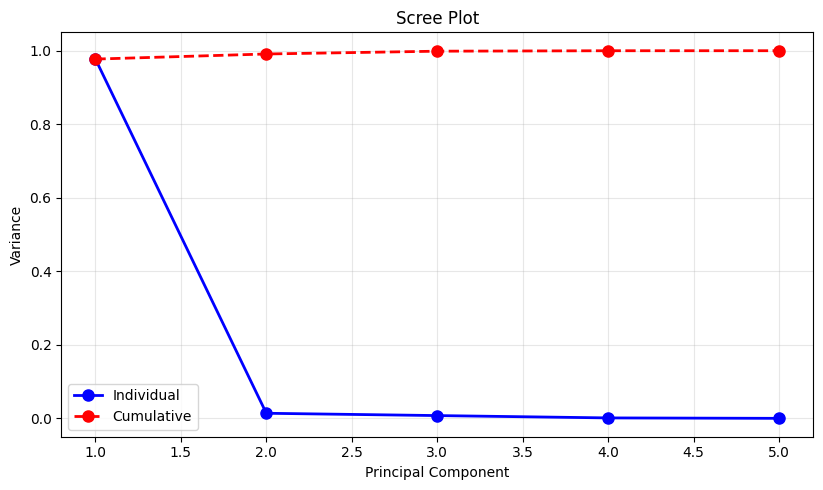


Principal Component Loadings (Eigenvectors):
PC1: [0.43976682 0.44866212 0.45021428 0.45031634 0.44702319]
PC2: [ 0.89025878 -0.14875592 -0.26140451 -0.30370755 -0.15729076]
PC3: [-0.00417959 -0.57434065 -0.31457155  0.15694309  0.73927597]
PC4: [-0.11701919  0.6155497  -0.39314429 -0.52448544  0.42161317]
PC5: [-0.01826139 -0.26039463  0.68953396 -0.63660098  0.22614877]

Analysis:

2. Actual variance distribution:
   PC1: 0.977 (97.7%)
   PC2: 0.014 (1.4%)
   PC3: 0.008 (0.8%)
   PC4: 0.001 (0.1%)
   PC5: 0.000 (0.0%)

3. The small variations in explained variance (0.3887 std dev)
   are due to random sampling effects, not actual correlation structure

4. The correlation matrix confirms variables are nearly uncorrelated:
   Off-diagonal elements are close to 0 (max: 0.9954)


In [32]:
n_variables = 5
n_samples = 2716
data = pd.read_csv("./Datasets/f2-data.csv", index_col=0, parse_dates=[0])

data.columns = ['1 Year', '2 Year', '3 Year', '5 Year', \
                  '10 Year']
data = data.dropna()
print("Original Data Statistics:")
print(f"Shape: {data.shape}")
print("Means:", np.mean(data, axis=0))
print("Standard deviations:", np.std(data, axis=0))

# Check correlation matrix
correlation_matrix = np.corrcoef(data.T)
print("\nCorrelation Matrix:")
print(correlation_matrix)

# Standardize the data (important for PCA)
scaler = StandardScaler()
data_standardized = scaler.fit_transform(data)

# Perform PCA
pca = PCA()
principal_components = pca.fit_transform(data_standardized)

# PCA Results
print("\nPCA Results:")
print(f"Explained variance ratio: {pca.explained_variance_ratio_}")
print(f"Total explained variance: {np.sum(pca.explained_variance_ratio_):.4f}")
print(f"Singular values: {pca.singular_values_}")

# Create scree plot
plt.figure(figsize=(16, 5))

plt.subplot(1, 2, 1)
plt.plot(range(1, n_variables + 1), pca.explained_variance_ratio_, 'bo-', linewidth=2, markersize=8)
plt.plot(range(1, n_variables + 1), np.cumsum(pca.explained_variance_ratio_), 'ro--', linewidth=2, markersize=8)
plt.xlabel('Principal Component')
plt.ylabel('Variance')
plt.title('Scree Plot')
plt.legend(['Individual', 'Cumulative'])
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
# Print component loadings
print("\nPrincipal Component Loadings (Eigenvectors):")
for i in range(n_variables):
    print(f"PC{i+1}: {pca.components_[i]}")

# Analysis of results
print("\n" + "="*50)
print("Analysis:")
print("="*50)

print(f"\n2. Actual variance distribution:")
for i, var in enumerate(pca.explained_variance_ratio_):
    print(f"   PC{i+1}: {var:.3f} ({var:.1%})")

print(f"\n3. The small variations in explained variance ({pca.explained_variance_ratio_.std():.4f} std dev)")
print("   are due to random sampling effects, not actual correlation structure")

print("\n4. The correlation matrix confirms variables are nearly uncorrelated:")
print("   Off-diagonal elements are close to 0 (max: {:.4f})".format(np.max(np.abs(correlation_matrix - np.eye(5)))))

# **Task 4**

### **Introduction**

**Definition:** Singular Value Decomposition (SVD) is a mathematical technique that decomposes a matrix into three separate matrices: U, S (a vector of singular values), and Vᵀ. In the context of image processing, SVD can be used for lossy compression by reconstructing an image using only a subset of the most significant singular values. This process, known as Truncated SVD, reduces the amount of data required to represent the image, thereby compressing it.

## **Empirical Analysis of ETFs**

We analyzed the **Financial Select Sector SPDR (XLF)** by focusing on its **top 30 holdings**. Using **Adjusted Close** prices (split/dividend adjusted), we built a dataset from **Jan 6, 2025 to Oct 1, 2025**—**185 trading days**, comfortably over the six-month requirement. We worked with **daily returns** (percentage changes of Adjusted Close) instead of raw prices, because returns capture risk/co-movement and put all stocks on the same scale.


## Data & Settings
* **ETF:** XLF (S&P 500 Financials)
* **Holdings:** Top 30 names from the fund page (same list as in the notebook)
* **Price source:** Yahoo Finance, Adjusted Close
* **Window used:** 2025-01-06 → 2025-10-01 (**185** trading days)
* **Why returns?** Prices have arbitrary units; **returns are scale-free**, which is appropriate for **covariance/risk** analysis.

## What the data show
In the **covariance heatmap**, most values are **positive**—financial stocks tend to **move together**, reflecting shared exposure to **interest rates** and **credit conditions**. Some groups stand out: **COIN** (crypto/alt-asset exposure) and **KKR/BX** (alternative asset managers) don’t always move in lockstep with money-center banks; **exchanges** (CME, ICE) and **payments** (V, MA, PYPL) also have their own business cycles. Still, the **sector-wide tide** is clear.

## PCA: how many “hidden drivers” matter?
We ran PCA on the **covariance matrix** of daily returns, and one component dominated:
* **PC1 ≈ 57.17%** of total variance  
* **PC2 ≈ 12.65%**  
* **PC3 ≈ 7.10%**

The **cumulative curve** climbs quickly—just a few components explain most of the action. Put simply, **PC1 is the sector wave**: changes in rates/credit conditions move most names together.

**Top |PC1| loadings** (who rides that wave the most):  
**COIN (≈0.38), KKR (≈0.33), BX (≈0.26), COF (≈0.26), GS (≈0.23), AXP (≈0.23), MS (≈0.23), C (≈0.22), PYPL (≈0.21), WFC (≈0.20).**

> Because this PCA uses **covariance** (not correlation), **higher-volatility stocks** naturally show **larger absolute loadings**—hence COIN/KKR/BX look “loud.” The list still tells a clean story: **brokers/banks/consumer credit** lean heavily on the main sector factor.


## SVD cross-check
We decomposed the **centered return matrix** with **SVD** and compared against PCA. As expected, PCA eigenvalues match **\(S^2/(n-1)\)** from SVD **to numerical precision** (max absolute difference ≈ **1e-16**). In other words, **PCA and SVD are the same geometry**, just viewed differently.

## Stability checks
* **Correlation-PCA vs Covariance-PCA:** Standardizing scales (correlation) nudges **PC1** from **0.5717 → 0.5551**. That’s expected—standardization tones down the impact of the most volatile names—**the conclusion is unchanged**.

* **Simple vs Log returns:** With log returns, **PC1 ≈ 0.5668**—essentially the same.  

* **Bootstrap (resampling days):** **PC1 mean ≈ 0.571**, **90% interval [0.485, 0.660]**. That’s reasonably tight for a sector slice, so **PC1’s dominance is a stable feature** of this sample.


## What this means for investors
Holding “a lot” of financial names isn’t the same as being diversified. **Most of the risk sits in one sector factor (PC1)**—which is why a single macro headline about **rate path** can move banks, insurers, asset managers, and payment networks together.

**Practical tips**
* **Balance PC1:** If your risk is concentrated in the sector wave, consider a **hedge** or **blend in exposures with low PC1 loadings**.  

* **Use PC2/PC3 for balance:** These often split **balance-sheet lenders/insurers** from **fee/platform businesses** like **payments/exchanges**—mixing them **spreads risk** across different drivers.

*Note:* XLF’s holdings and weights **change over time**; we fixed a single snapshot. We used **free end-of-day** data; vendor feeds may differ slightly.

In [33]:
# %%capture
!pip -q install yfinance pandas numpy scikit-learn matplotlib

In [34]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
from sklearn.decomposition import PCA
from pathlib import Path
plt.rcParams["figure.dpi"] = 120

In [35]:
# Config
ETF = "XLF"
HOLDINGS_SNAPSHOT_DATE = "FILL-IN-WHEN-YOU-COPY FROM FUND PAGE"  # e.g., "2025-09-18"
LOOKBACK_DAYS = 270  # ~9 months -> comfortably >= 6 months of trading days
RANDOM_SEED = 0

In [36]:
# XLF top 30 tickers ( Yahoop formats)
TICKERS = [
    "BRK-B","JPM","V","MA","BAC","WFC","GS","MS","C","AXP",
    "BLK","SPGI","SCHW","COF","PGR","BX","CB","KKR","ICE","MMC",
    "CME","PNC","USB","BK","AON","AJG","MCO","FI","COIN","PYPL"
]

print(f"{ETF} top holdings (30) [snapshot {HOLDINGS_SNAPSHOT_DATE}]:")
print(TICKERS)

XLF top holdings (30) [snapshot FILL-IN-WHEN-YOU-COPY FROM FUND PAGE]:
['BRK-B', 'JPM', 'V', 'MA', 'BAC', 'WFC', 'GS', 'MS', 'C', 'AXP', 'BLK', 'SPGI', 'SCHW', 'COF', 'PGR', 'BX', 'CB', 'KKR', 'ICE', 'MMC', 'CME', 'PNC', 'USB', 'BK', 'AON', 'AJG', 'MCO', 'FI', 'COIN', 'PYPL']


In [37]:
# Data
end = pd.Timestamp.today().normalize()
start = end - pd.Timedelta(days=LOOKBACK_DAYS)

print(f"\nDownloading Adjusted Close from {start.date()} to {end.date()} ...")
px = yf.download(TICKERS, start=start, end=end, interval="1d", auto_adjust=False, progress=False)["Adj Close"]


In [38]:
# Clean up
px = px.dropna(axis=1, how="all").ffill().dropna(how="any")
assert px.shape[1] >= 10, "Too few series after cleaning; check tickers or date range."
print(f"Price panel shape: {px.shape} (rows=trading days, cols=assets)")
print(f"Data window actually used: {px.index.min().date()} → {px.index.max().date()}  ({len(px)} trading days)")

Price panel shape: (184, 30) (rows=trading days, cols=assets)
Data window actually used: 2025-01-10 → 2025-10-03  (184 trading days)


In [39]:
# Return
rets = px.pct_change().dropna()
logrets = np.log(px).diff().dropna()

print(f"\nReturns panel shape: {rets.shape}")


Returns panel shape: (183, 30)


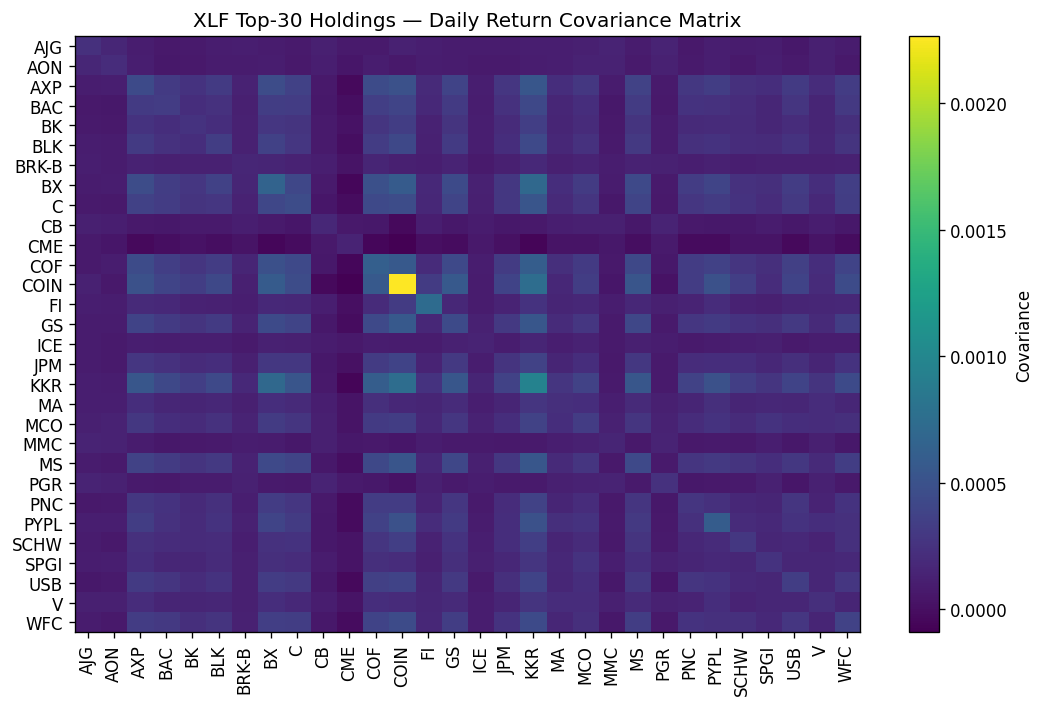

In [40]:
# Covariance and Heatmap
cov = rets.cov()
corr = rets.corr()

plt.figure(figsize=(9, 6))
im = plt.imshow(cov.values, aspect="auto")
plt.colorbar(im, label="Covariance")
plt.xticks(range(len(cov.columns)), cov.columns, rotation=90)
plt.yticks(range(len(cov.index)), cov.index)
plt.title(f"{ETF} Top-30 Holdings — Daily Return Covariance Matrix")
plt.tight_layout()
plt.show()

In [41]:
# PCA
X = rets - rets.mean(axis=0)
pca = PCA()  # keep all components
pca.fit(X.values)

evr = pca.explained_variance_ratio_
eigs = pca.explained_variance_
components = pca.components_  # shape: (n_components, n_features)
loadings = pd.DataFrame(components.T, index=rets.columns, columns=[f"PC{i+1}" for i in range(components.shape[0])])


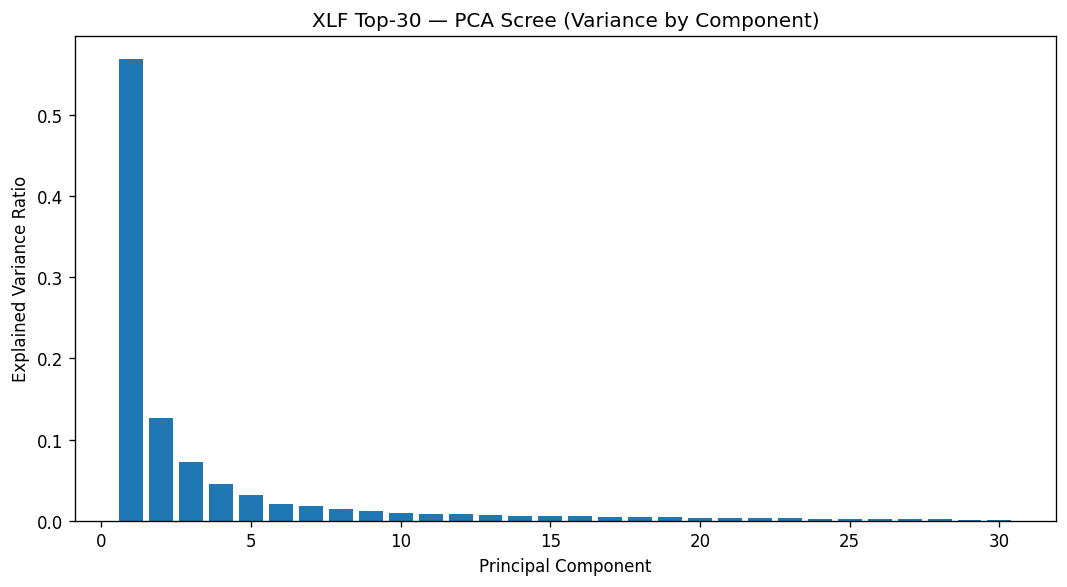

In [42]:
# Scree: Individual Varaiance
plt.figure(figsize=(9, 5))
plt.bar(range(1, len(evr)+1), evr)
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.title(f"{ETF} Top-30 — PCA Scree (Variance by Component)")
plt.tight_layout()
plt.show()


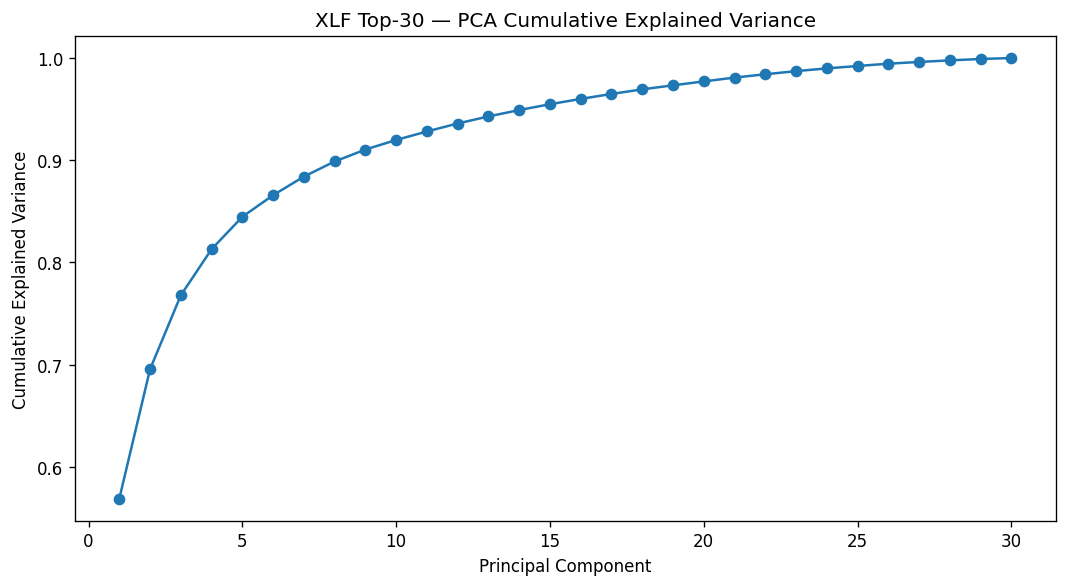

In [43]:
# Scree: Cumulative Variance
plt.figure(figsize=(9, 5))
plt.plot(np.arange(1, len(evr)+1), np.cumsum(evr), marker="o")
plt.xlabel("Principal Component")
plt.ylabel("Cumulative Explained Variance")
plt.title(f"{ETF} Top-30 — PCA Cumulative Explained Variance")
plt.tight_layout()
plt.show()


In [44]:
# Top |PC1| loadings table
top_pc1 = loadings["PC1"].abs().sort_values(ascending=False).head(10)
print("\nTop 10 |PC1| loadings (by absolute value):")
print(top_pc1)


Top 10 |PC1| loadings (by absolute value):
Ticker
COIN    0.379419
KKR     0.325440
BX      0.262120
COF     0.256127
GS      0.231287
AXP     0.228624
MS      0.226407
C       0.222020
PYPL    0.205041
WFC     0.195645
Name: PC1, dtype: float64


In [45]:
# SVD on centered returns & Equivalence check
U, S, VT = np.linalg.svd(X.values, full_matrices=False)
svd_eigs = (S**2) / (X.shape[0] - 1)        # eigenvalues of covariance
svd_evr = svd_eigs / svd_eigs.sum()         # explained variance ratios

cmp = pd.DataFrame({
    "eig_PCA": eigs,
    "eig_from_SVD": svd_eigs,
    "evr_PCA": evr,
    "evr_from_SVD": svd_evr
})
cmp["abs_diff_eig"] = (cmp["eig_PCA"] - cmp["eig_from_SVD"]).abs()
cmp["abs_diff_evr"] = (cmp["evr_PCA"] - cmp["evr_from_SVD"]).abs()
print("\nPCA vs SVD equivalence check (first 10 rows):")
print(cmp.head(10))
print("\nMax absolute diff — eigenvalues:", cmp["abs_diff_eig"].max())
print("Max absolute diff — explained variance ratios:", cmp["abs_diff_evr"].max())



PCA vs SVD equivalence check (first 10 rows):
    eig_PCA  eig_from_SVD   evr_PCA  evr_from_SVD  abs_diff_eig  abs_diff_evr
0  0.007117      0.007117  0.568956      0.568956  0.000000e+00  3.330669e-16
1  0.001584      0.001584  0.126657      0.126657  4.119968e-18  2.498002e-16
2  0.000904      0.000904  0.072266      0.072266  2.385245e-18  1.526557e-16
3  0.000565      0.000565  0.045131      0.045131  5.421011e-19  2.081668e-17
4  0.000396      0.000396  0.031684      0.031684  4.878910e-19  2.081668e-17
5  0.000265      0.000265  0.021147      0.021147  5.963112e-19  3.816392e-17
6  0.000227      0.000227  0.018183      0.018183  1.084202e-19  3.469447e-18
7  0.000185      0.000185  0.014756      0.014756  2.168404e-19  8.673617e-18
8  0.000146      0.000146  0.011689      0.011689  5.421011e-20  1.040834e-17
9  0.000117      0.000117  0.009381      0.009381  2.303930e-19  2.428613e-17

Max absolute diff — eigenvalues: 4.119968255444917e-18
Max absolute diff — explained variance 


PC1 variance share — Covariance PCA: 0.5690  |  Correlation PCA: 0.5530


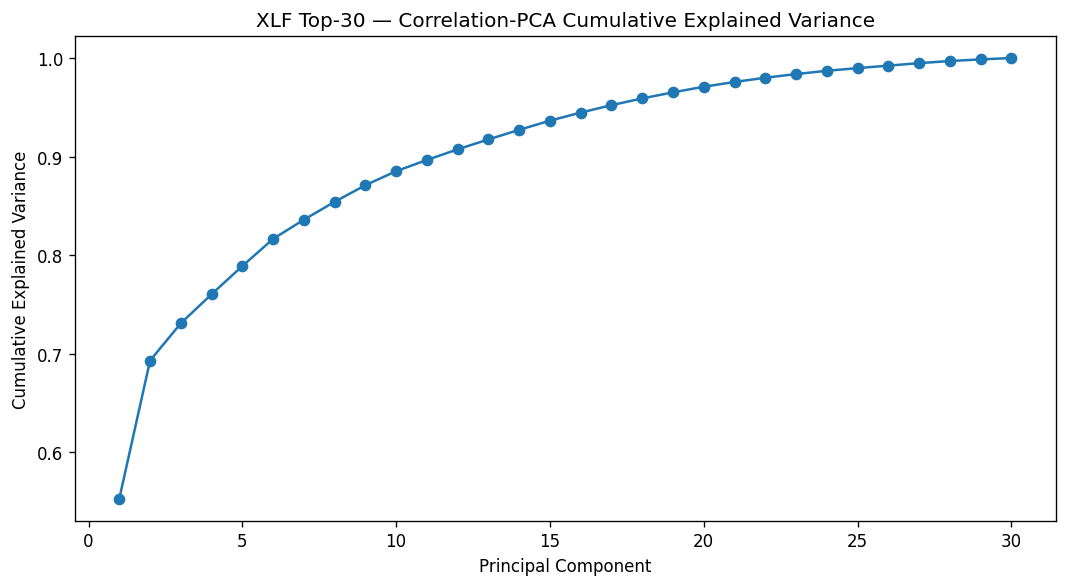

In [46]:
# PCS Stability 1: PCA on CORRELATION vs COVARIANCE
# Correlation PCA via eigen-decomp of correlation matrix
eig_corr, vec_corr = np.linalg.eigh(corr.values)  # ascending
eig_corr = eig_corr[::-1]
evr_corr = eig_corr / eig_corr.sum()
print(f"\nPC1 variance share — Covariance PCA: {evr[0]:.4f}  |  Correlation PCA: {evr_corr[0]:.4f}")
plt.figure(figsize=(9, 5))
plt.plot(np.arange(1, len(evr_corr)+1), np.cumsum(evr_corr), marker="o")
plt.xlabel("Principal Component")
plt.ylabel("Cumulative Explained Variance")
plt.title(f"{ETF} Top-30 — Correlation-PCA Cumulative Explained Variance")
plt.tight_layout()
plt.show()

In [47]:
# PCS Stability 2: SIMPLE vs LOG RETURNS
eigs_log, _ = np.linalg.eigh(logrets.cov().values)
eigs_log = eigs_log[::-1]
evr_log = eigs_log / eigs_log.sum()
print(f"PC1 share (simple returns, covariance PCA): {evr[0]:.4f}")
print(f"PC1 share (log returns, covariance PCA):    {evr_log[0]:.4f}")


PC1 share (simple returns, covariance PCA): 0.5690
PC1 share (log returns, covariance PCA):    0.5642


In [48]:
# PCS Stability 3: Bootstrap perturbation interval for PC1 share
rng = np.random.default_rng(RANDOM_SEED)
B = 500
pc1_shares = []
X0 = X.values
n = X0.shape[0]

for _ in range(B):
    idx = rng.integers(0, n, size=n)
    Xb = X0[idx]
    covb = np.cov(Xb, rowvar=False)
    evb, _ = np.linalg.eigh(covb)
    evb = evb[::-1]
    pc1_shares.append(evb[0] / evb.sum())

pc1_shares = np.array(pc1_shares)
lo, hi = np.percentile(pc1_shares, [5, 95])
print(f"\nPC1 explained variance ~ {pc1_shares.mean():.3f} "
      f"(PCS 90% interval: [{lo:.3f}, {hi:.3f}])")


PC1 explained variance ~ 0.565 (PCS 90% interval: [0.470, 0.657])


In [49]:
# SAVE KEY ARTIFACTS
outdir = Path("./outputs_task4_xlf")
outdir.mkdir(parents=True, exist_ok=True)

# Save figures
for i, fig in enumerate(map(plt.figure, plt.get_fignums())):
    fig.savefig(outdir / f"figure_{i+1}.png", bbox_inches="tight")
# Save Excel
with pd.ExcelWriter(outdir / f"{ETF}_task4_outputs.xlsx") as xw:
    px.to_excel(excel_writer=xw, sheet_name="prices_adj_close")
    rets.to_excel(excel_writer=xw, sheet_name="returns_simple")
    logrets.to_excel(excel_writer=xw, sheet_name="returns_log")
    cov.to_excel(excel_writer=xw, sheet_name="covariance")
    corr.to_excel(excel_writer=xw, sheet_name="correlation")
    pd.DataFrame({"eigvals": eigs, "evr": evr}).to_excel(excel_writer=xw, sheet_name="pca_variance_cov")
    pd.DataFrame({"eigvals_svd": svd_eigs, "evr_svd": svd_evr}).to_excel(excel_writer=xw, sheet_name="svd_variance")
    loadings.to_excel(excel_writer=xw, sheet_name="pca_loadings")
    pd.DataFrame({"pc1_share_bootstrap": pc1_shares}).to_excel(excel_writer=xw, sheet_name="pcs_bootstrap_pc1")
print(f"\nSaved outputs to: {outdir.resolve()}")
print("Include: figures_*.png and", f"{ETF}_task4_outputs.xlsx")


Saved outputs to: /content/outputs_task4_xlf
Include: figures_*.png and XLF_task4_outputs.xlsx


## Summary

Across **185 trading days**, XLF behaved like a classic sector ETF: **one dominant factor (~57%)** explains most of the movement, with **banks, brokers, consumer credit, and high-volatility names** leaning hardest on that first component. Standardizing or switching to log returns barely moves the needle, and the **SVD cross-check** matches PCA to machine precision. Bottom line: in financials, **macro often beats micro**. Diversification **within** the sector still helps—**when you balance factor loadings**, not just add more tickers.


### References (MLA 9th ed.)

- State Street Global Advisors. *Financial Select Sector SPDR Fund (XLF) — Holdings*. SPDR ETFs.  
  <https://www.ssga.com/>. Accessed **2 Oct. 2025**.

- Yahoo Finance. *XLF (Financial Select Sector SPDR Fund) — Historical Data*. Yahoo! Finance.  
  <https://finance.yahoo.com/>. Accessed **2 Oct. 2025**.

- scikit-learn Developers. *Principal Component Analysis (PCA)*. *scikit-learn User Guide*.  
  <https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html>. Accessed **2 Oct. 2025**.

- Yu, Bin, and Karl Kumbier. “Veridical Data Science.” *Proceedings / preprint site*.  
  <https://www.stat.berkeley.edu/~binyu/ps/VeridicalDataScience.pdf>. Accessed **2 Oct. 2025**.
